In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Ready to go!")

Ready to go!


In [2]:
import urllib.request

url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/retail_sales.csv"
urllib.request.urlretrieve(url, "retail_sales.csv")
print("Dataset downloaded successfully!")

HTTPError: HTTP Error 404: Not Found

In [3]:
import urllib.request

url = "https://raw.githubusercontent.com/dsrscientist/dataset1/refs/heads/master/retail_sales.csv"
urllib.request.urlretrieve(url, "retail_sales.csv")
print("Downloaded!")

HTTPError: HTTP Error 404: Not Found

In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)
dates = pd.date_range(start='2023-01-01', periods=500, freq='D')
categories = ['Electronics', 'Clothing', 'Food', 'Beauty', 'Sports']
genders = ['Male', 'Female']

df = pd.DataFrame({
    'Date': np.random.choice(dates, 500),
    'Category': np.random.choice(categories, 500),
    'Gender': np.random.choice(genders, 500),
    'Age': np.random.randint(18, 65, 500),
    'Quantity': np.random.randint(1, 10, 500),
    'Price_per_Unit': np.random.randint(10, 500, 500),
})

df['Sales'] = df['Quantity'] * df['Price_per_Unit']
df.to_csv('retail_sales.csv', index=False)

print("Dataset created!")
print("Shape:", df.shape)
print(df.head())

Dataset created!
Shape: (500, 7)
        Date  Category  Gender  Age  Quantity  Price_per_Unit  Sales
0 2023-04-13  Clothing    Male   31         3             271    813
1 2024-03-11      Food  Female   48         1             428    428
2 2023-12-15  Clothing    Male   35         6             415   2490
3 2023-09-28  Clothing  Female   24         2             436    872
4 2023-04-17  Clothing  Female   27         3             152    456


In [5]:
df = pd.read_csv('retail_sales.csv')
print("Shape:", df.shape)
print(df.head())
print(df.info())

Shape: (500, 7)
         Date  Category  Gender  Age  Quantity  Price_per_Unit  Sales
0  2023-04-13  Clothing    Male   31         3             271    813
1  2024-03-11      Food  Female   48         1             428    428
2  2023-12-15  Clothing    Male   35         6             415   2490
3  2023-09-28  Clothing  Female   24         2             436    872
4  2023-04-17  Clothing  Female   27         3             152    456
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Date            500 non-null    str  
 1   Category        500 non-null    str  
 2   Gender          500 non-null    str  
 3   Age             500 non-null    int64
 4   Quantity        500 non-null    int64
 5   Price_per_Unit  500 non-null    int64
 6   Sales           500 non-null    int64
dtypes: int64(4), str(3)
memory usage: 27.5 KB
None


In [6]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
print("Cleaned! Shape:", df.shape)

Cleaned! Shape: (500, 7)


In [7]:
print("=== BASIC STATISTICS ===")
print(df.describe())
print("\nMean Sales:  ", round(df['Sales'].mean(), 2))
print("Median Sales:", round(df['Sales'].median(), 2))
print("Std Dev:     ", round(df['Sales'].std(), 2))
print("Max Sales:   ", df['Sales'].max())
print("Min Sales:   ", df['Sales'].min())

=== BASIC STATISTICS ===
                             Date         Age    Quantity  Price_per_Unit  \
count                         500  500.000000  500.000000      500.000000   
mean   2023-09-10 02:55:40.800000   41.882000    4.988000      255.948000   
min           2023-01-02 00:00:00   18.000000    1.000000       12.000000   
25%           2023-05-14 18:00:00   30.000000    3.000000      133.000000   
50%           2023-09-09 00:00:00   42.000000    5.000000      251.000000   
75%           2024-01-09 06:00:00   53.000000    7.000000      391.500000   
max           2024-05-14 00:00:00   64.000000    9.000000      499.000000   
std                           NaN   13.365678    2.607192      144.302709   

             Sales  
count   500.000000  
mean   1229.134000  
min      28.000000  
25%     436.000000  
50%     973.500000  
75%    1800.000000  
max    4473.000000  
std     990.775003  

Mean Sales:   1229.13
Median Sales: 973.5
Std Dev:      990.78
Max Sales:    4473
Min Sales

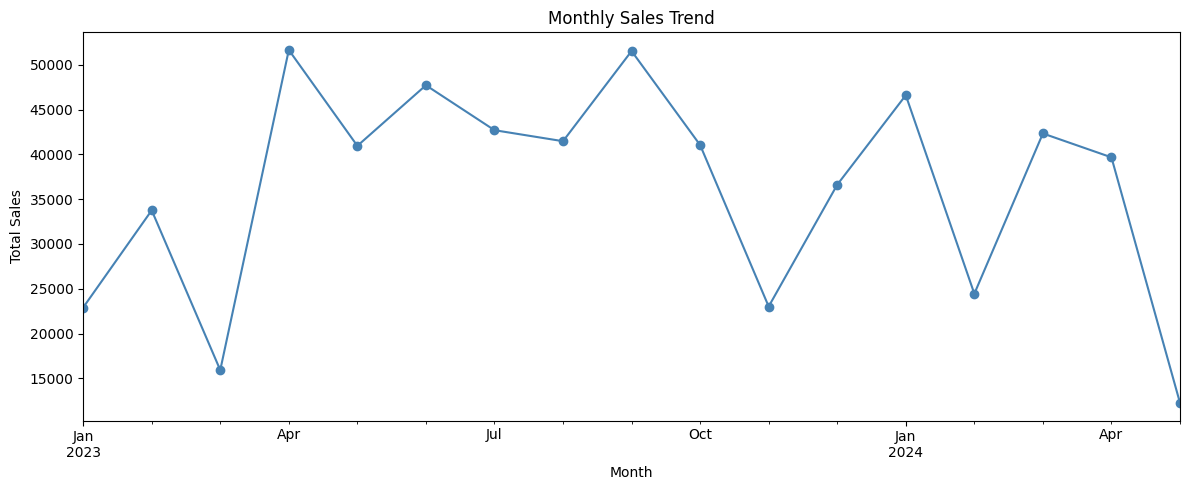

Chart saved!


In [8]:
df['Month'] = df['Date'].dt.to_period('M')
monthly = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12, 5))
monthly.plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('monthly_sales.png')
plt.show()
print("Chart saved!")

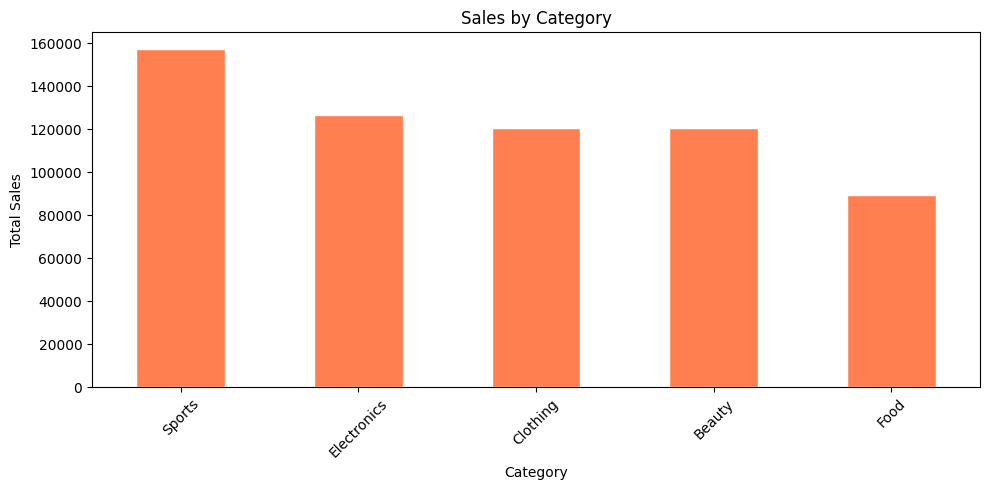

Chart saved!


In [9]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
category_sales.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('category_sales.png')
plt.show()
print("Chart saved!")

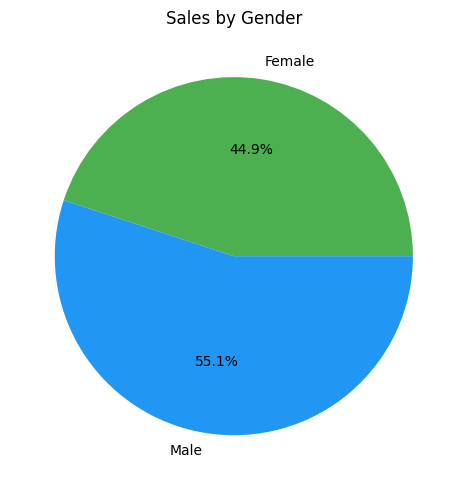

Chart saved!


In [10]:
gender_sales = df.groupby('Gender')['Sales'].sum()

plt.figure(figsize=(6, 5))
gender_sales.plot(kind='pie', autopct='%1.1f%%',
                  colors=['#4CAF50','#2196F3'])
plt.title('Sales by Gender')
plt.ylabel('')
plt.tight_layout()
plt.savefig('gender_sales.png')
plt.show()
print("Chart saved!")

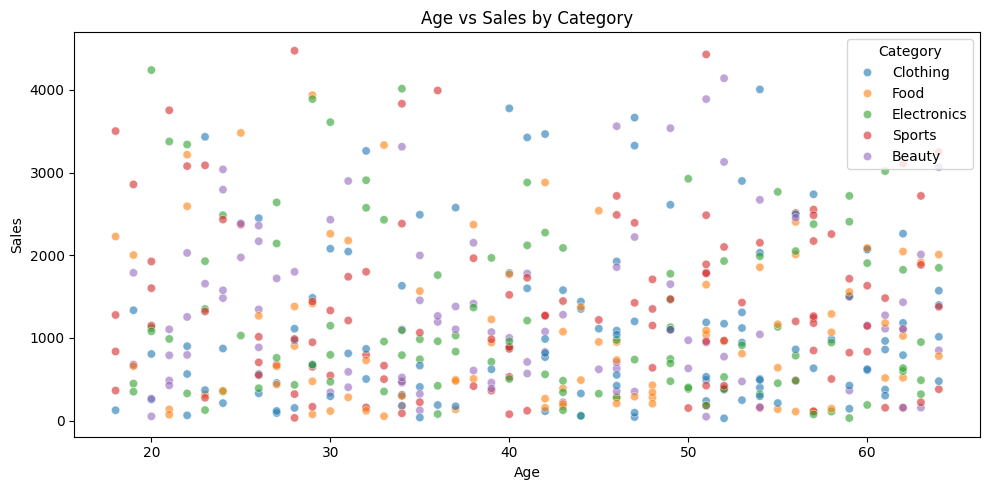

Chart saved!


In [11]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Age', y='Sales', hue='Category', alpha=0.6)
plt.title('Age vs Sales by Category')
plt.tight_layout()
plt.savefig('age_vs_sales.png')
plt.show()
print("Chart saved!")

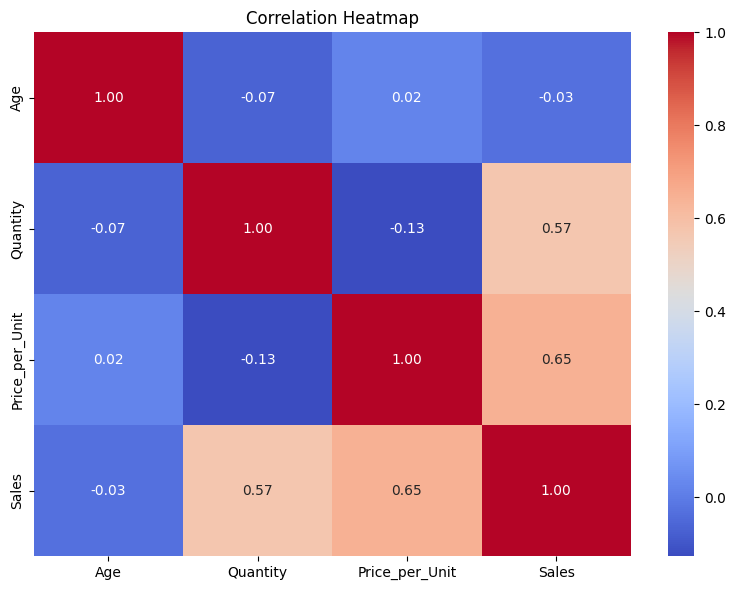

Chart saved!


In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()
print("Chart saved!")

In [13]:
print("========== PROJECT 1 SUMMARY ==========")
print(f"Total Records     : {len(df)}")
print(f"Date Range        : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Total Revenue     : Rs. {df['Sales'].sum():,.2f}")
print(f"Average Sale      : Rs. {round(df['Sales'].mean(), 2):,.2f}")
print(f"Best Category     : {category_sales.index[0]}")
print(f"Worst Category    : {category_sales.index[-1]}")
print(f"Best Month        : {monthly.idxmax()}")
print("========================================")
print("All charts saved as PNG files!")
print("Project 1 Complete!")

========== PROJECT 1 SUMMARY ==========
Total Records     : 500
Date Range        : 2023-01-02 to 2024-05-14
Total Revenue     : Rs. 614,567.00
Average Sale      : Rs. 1,229.13
Best Category     : Sports
Worst Category    : Food
Best Month        : 2023-04
All charts saved as PNG files!
Project 1 Complete!
